# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import warnings
import zipfile
import pandas as pd
import os
import json
!pip install optuna
!pip install optuna-integration[lightgbm]
import optuna
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, brier_score_loss,  roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
warnings.filterwarnings("ignore")

# **Load Data**

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/gdrive')

gdrive_zip_path = '/content/gdrive/MyDrive/End_to_End_Fraud_Detection_Model/fraudTrain.csv.zip'

extract_dir = './data/'
os.makedirs(extract_dir, exist_ok=True)

# Extract the CSV file
with zipfile.ZipFile(gdrive_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    print(f"Extracted {zip_ref.namelist()[0]} to {extract_dir}")

# Load the extracted CSV file into a DataFrame
csv_file_name = zip_ref.namelist()[0]
LC_PATH = os.path.join(extract_dir, csv_file_name)

df_total = pd.read_csv(LC_PATH, low_memory=False)

display(df_total.head())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Extracted fraudTrain.csv to ./data/


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df_total.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

# **Feature Engineering**

We first generate the following features:

* **calendar context features**
  * day of week (`dow`)
  * `hour`
  * `is_weekend`
  * `is_night`
  * `day_of_year`
  * `day_of_month`
  * `is_month_end`
  * `week_of_year`
* distance in km (`distance_km`)
* **amount features**
  * `log_amt` — amount is right skewed.
  * `inverse_amt` — helps catch micro-probing attacks.
  * `log_inverse_amt`






In [4]:
# Add Calendar Features
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dow'] = df['trans_date_trans_time'].dt.dayofweek
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
    df["day_of_year"] = df["trans_date_trans_time"].dt.dayofyear.astype(np.int16)
    df["day_of_month"] = df["trans_date_trans_time"].dt.day.astype(np.int8)
    df["is_month_end"] = (df["trans_date_trans_time"].dt.day >= 28).astype(np.int8)
    df["week_of_year"] = df["trans_date_trans_time"].dt.isocalendar().week.astype(np.int8)
    return df

# Add distance feature
def haversine_km(lat1, lon1, lat2, lon2):
      R = 6371.0
      lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
      dlat = lat2 - lat1
      dlon = lon2 - lon1
      a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
      return 2 * R * np.arcsin(np.sqrt(a))

def add_distance_feature(df: pd.DataFrame) -> pd.DataFrame:
  df["distance_km"] = haversine_km(
        df["lat"].values, df["long"].values,
        df["merch_lat"].values, df["merch_long"].values,
    ).astype(np.float32)
  return df

# add amt features
def add_amt_features(df: pd.DataFrame) -> pd.DataFrame:
    df['amt'] = df['amt'].astype(float)
    # amt is skewed right
    df['log_amt'] = np.log(df['amt'])
    # to catch micro-probing attacks
    df['inverse_amt'] = 1 / df['amt']
    df['log_inverse_amt'] = np.log(df['inverse_amt'])
    return df

In [5]:
df_total.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

**Velocity features:** Fraud signal lives in short-window velocity features. We engineer four card-level features over a rolling **1-hour** window:

- `cc_cnt_1h` — transaction count
- `cc_amt_1h` — total transaction amount
- `cc_distinct_category_1h` — distinct merchant categories
- `cc_distinct_merchant_1h` — distinct merchants.

We will also add time since previous transaction feature (`cc_time_since_prev_s`).

At inference time, these are served from the online feature store and updated in real time as transactions arrive.

In [6]:
# Add 1 hour rolling features
def one_hour_rolling(df: pd.DataFrame, win: str, name: str) -> pd.DataFrame:
  def _roll(sub, _win=win, _name=name):
      s = sub.set_index("trans_date_trans_time")["amt"]
      cnt = s.rolling(_win).count().shift(1)
      amt = s.rolling(_win).sum().shift(1)
      return pd.DataFrame(
          {f"cc_cnt_{_name}": cnt.values, f"cc_amt_{_name}": amt.values},
          index=sub.index,
      )
  rolled = df.groupby("cc_num", sort=False, group_keys=False).apply(_roll)
  df[f"cc_cnt_{name}"] = rolled[f"cc_cnt_{name}"].astype(np.float32)
  df[f"cc_amt_{name}"] = rolled[f"cc_amt_{name}"].astype(np.float32)
  return df

# Add time since previous transaction
def time_since_prev_trans(df):
  df["cc_time_since_prev_s"] = (
        df.groupby("cc_num")["trans_date_trans_time"]
          .diff()
          .dt.total_seconds()
          .astype(np.float32)
    )
  return df

In [7]:
# add distinct category and merchant features
def add_distinct(df: pd.DataFrame, win: str, name: str, col: str) -> pd.DataFrame:
  df = df.sort_values(["cc_num", "trans_date_trans_time"]).reset_index(drop=True)

  df[f"{col}_code"] = df[col].astype("category").cat.codes.astype(np.int32)

  def _distinct_cats(sub, _win = win, _name = col):
      s = sub.set_index("trans_date_trans_time")[f"{_name}_code"]
      out = s.rolling(_win).apply(lambda x: np.unique(x).size, raw=True).shift(1)
      return pd.Series(out.values, index=sub.index)

  df[f"cc_distinct_{col}_{name}"] = df.groupby("cc_num", sort=False, group_keys=False).apply(_distinct_cats).astype(np.float32)
  return df


In [8]:
df_total['trans_date_trans_time'] = pd.to_datetime(df_total['trans_date_trans_time'])
df_total = df_total.sort_values(["cc_num", "trans_date_trans_time"]).reset_index(drop=True)
df_total = add_calendar_features(df_total)
df_total = add_distance_feature(df_total)
df_total = add_amt_features(df_total)
df_total = one_hour_rolling(df_total, "1H", "1h")
df_total = time_since_prev_trans(df_total)
df_total = add_distinct(df_total, "1H", "1h", "category")
df_total = add_distinct(df_total, "1H", "1h", "merchant")

In [9]:
df_total.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'dow', 'hour', 'is_weekend',
       'is_night', 'day_of_year', 'day_of_month', 'is_month_end',
       'week_of_year', 'distance_km', 'log_amt', 'inverse_amt',
       'log_inverse_amt', 'cc_cnt_1h', 'cc_amt_1h', 'cc_time_since_prev_s',
       'category_code', 'cc_distinct_category_1h', 'merchant_code',
       'cc_distinct_merchant_1h'],
      dtype='object')

# **Nightly Batch Features**

**Nightly batch features:** We will compute six card-level aggregates over trailing windows `[D − k, D)` , strictly excluding the scoring day `D` with `k ∈ {7, 30}`:

- `cc_amt_30d`, `cc_cnt_30d` — 30-day spend total and transaction count
- `cc_amt_mean_7d`, `cc_amt_std_7d` — 7-day mean and standard deviation of transaction amount
- `cc_amt_mean_30d`, `cc_amt_std_30d` — 30-day mean and standard deviation of transaction amount

**Example:**

For a transaction scored at `2020-06-15 12:02:47`:

* the scoring day is `D = 2020-06-15`
* the 7-day window spans `[2020-06-08 00:00:00, 2020-06-15 00:00:00)`
* the 30-day window spans `[2020-05-16 00:00:00, 2020-06-15 00:00:00)`.

Any transaction on `2020-06-15`, including earlier ones are excluded from both aggregates.

In production, these fetures are computed offline in a nightly batch job and and pushed to the online the feature store. At inference, they are fetched directly, without runtime computation.

In [10]:
def add_nightly_features(df_tot: pd.DataFrame) -> pd.DataFrame:
    CARD_COL = "cc_num"
    df_tot["day"] = df_tot["trans_date_trans_time"].dt.floor("D")
    df = df_tot[['trans_date_trans_time', 'amt', CARD_COL, 'day']].copy()
    # amout squared for std calculation
    df["amount_sq"] = df['amt'] ** 2
    CARD_COL = "cc_num"

    # get daily aggs and cummulative sums
    daily_card =  df.groupby([CARD_COL, "day"], sort=False, observed=True).agg(
        amount_sum=('amt', "sum"),
        amount_sq_sum=("amount_sq", "sum"),
        amount_n=('amt', "size"),
    ).reset_index().sort_values([CARD_COL, "day"], kind="mergesort").reset_index(drop=True)

    cum_cols = ["amount_sum", "amount_sq_sum", "amount_n"]

    daily_card[[f"cum_{c}" for c in cum_cols]] = daily_card.groupby(CARD_COL, sort=False)[cum_cols].cumsum()


    cum_card = daily_card[[CARD_COL, "day", "cum_amount_sum", "cum_amount_sq_sum", "cum_amount_n"]].sort_values(
        ["day", CARD_COL], kind="mergesort").reset_index(drop=True)

    card_days = df[[CARD_COL, "day"]].drop_duplicates().sort_values([CARD_COL, "day"], kind="mergesort").reset_index(drop=True)

    # get cumulative strictly before day D
    end = pd.merge_asof(
        card_days.sort_values(["day", CARD_COL], kind="mergesort"),
        cum_card,
        on="day",
        by=CARD_COL,
        direction="backward",
        allow_exact_matches=False,
    ).rename(columns={
        "cum_amount_sum":    "end_amount_sum",
        "cum_amount_sq_sum": "end_amount_sq_sum",
        "cum_amount_n":      "end_amount_n",
    })

    #print(end.head())
    # get start boundary at D - k days
    def start_boundary(days: int, suffix: str) -> pd.DataFrame:
      s = card_days.copy()
      s[f"cutoff_{suffix}"] = s["day"] - pd.Timedelta(days=days)

      right = cum_card.rename(columns={"day": "cum_day"})

      s = pd.merge_asof(
          s.sort_values([f"cutoff_{suffix}", CARD_COL], kind="mergesort"),
          right.sort_values(["cum_day", CARD_COL], kind="mergesort"),
          left_on=f"cutoff_{suffix}",
          right_on="cum_day",
          by=CARD_COL,
          direction="backward",
          allow_exact_matches=True,
      )
      #print(s.head())
      return s.rename(columns={
          "cum_amount_sum":    f"start_amount_sum_{suffix}",
          "cum_amount_sq_sum": f"start_amount_sq_sum_{suffix}",
          "cum_amount_n":      f"start_amount_n_{suffix}",
      })[[CARD_COL, "day",
          f"start_amount_sum_{suffix}",
          f"start_amount_sq_sum_{suffix}",
          f"start_amount_n_{suffix}"]]


    start_7  = start_boundary(7,  "7d")
    start_30 = start_boundary(30, "30d")

    end = end[[CARD_COL, "day", "end_amount_sum", "end_amount_sq_sum", "end_amount_n"]]
    # merge to end
    card_features = end.merge(start_7,  on=[CARD_COL, "day"], how="left")\
    .merge(start_30, on=[CARD_COL, "day"], how="left")


    # add features
    def add_features(feats: pd.DataFrame, suffix: str):
        n   = feats["end_amount_n"]    - feats[f"start_amount_n_{suffix}"].fillna(0)
        sum   = feats["end_amount_sum"]  - feats[f"start_amount_sum_{suffix}"].fillna(0)
        sq_sum  = feats["end_amount_sq_sum"] - feats[f"start_amount_sq_sum_{suffix}"].fillna(0)

        feats[f"cc_amt_{suffix}"] = sum
        feats[f"cc_cnt_{suffix}"] = n

        no_history = feats["end_amount_n"].isna()
        feats.loc[no_history, [f"cc_cnt_{suffix}", f"cc_amt_{suffix}"]] = [0, np.nan]

        mean = sum / n
        feats[f"cc_amt_mean_{suffix}"] = mean

        # population variance: E[X^2] - E[X]^2
        var = (sq_sum / n) - mean**2
        var = var.clip(lower=0)

        feats[f"cc_amt_std_{suffix}"] = np.sqrt(var)

        feats.loc[n == 0, [f"cc_amt_mean_{suffix}",
                        f"cc_amt_std_{suffix}"]] = np.nan

    add_features(card_features, "7d")
    add_features(card_features, "30d")

    df_tot = df_tot.merge(
        card_features[[
            CARD_COL, "day", 'cc_amt_7d', 'cc_cnt_7d',
            'cc_amt_30d', 'cc_cnt_30d',
            "cc_amt_mean_7d",  "cc_amt_std_7d",
            "cc_amt_mean_30d", "cc_amt_std_30d",
        ]],
        on=[CARD_COL, "day"],
        how="left",
    )

    return df_tot
df_total = add_nightly_features(df_total)
df_total.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,cc_distinct_merchant_1h,day,cc_amt_7d,cc_cnt_7d,cc_amt_30d,cc_cnt_30d,cc_amt_mean_7d,cc_amt_std_7d,cc_amt_mean_30d,cc_amt_std_30d
0,1017,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,...,NaN,2019-01-01,NaN,0.0,NaN,0.0,NaN,NaN,NaN,NaN
1,2724,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,...,1.0,2019-01-02,7.27,1.0,7.27,1.0,7.27,0.0,7.27,0.0
2,2726,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,...,1.0,2019-01-02,7.27,1.0,7.27,1.0,7.27,0.0,7.27,0.0
3,2882,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,Mary,Diaz,F,9886 Anita Drive,...,2.0,2019-01-02,7.27,1.0,7.27,1.0,7.27,0.0,7.27,0.0
4,2907,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,Mary,Diaz,F,9886 Anita Drive,...,1.0,2019-01-02,7.27,1.0,7.27,1.0,7.27,0.0,7.27,0.0


# **Hourly Features**

To bridge the gap between real-time 1-hour velocity and nightly baselines, we will add two card-level aggregates over the trailing 24 hours window [H − 24h, H), excluding the current hour:

- `cc_amt_24h` — total transaction amount in the last 24 hours
- `cc_cnt_24h` — transaction count in the last 24 hours


**Example:**

For a transaction scored at `2020-06-15 12:02:47`:

* the current hour is `H = 2020-06-15 12:00:00`
* the window spans `[2020-06-14 12:00:00, 2020-06-15 12:00:00)`.

In production, these can be produced by a Flink job emitting aggregates on the hour, or by an hourly batch job, and pushed to the online feature store. At inference, they are fetched directly, without runtime computation.

In [11]:
def add_24H_Hourly_features(df_tot: pd.DataFrame) -> pd.DataFrame:
    CARD_COL = "cc_num"
    df_tot["hour_bucket"] = df_tot["trans_date_trans_time"].dt.floor("h")
    df = df_tot[['trans_date_trans_time', 'amt', CARD_COL, 'hour_bucket']].copy()
    CARD_COL = "cc_num"

    # get daily aggs and cummulative sums
    hourly_card =  df.groupby([CARD_COL, "hour_bucket"], sort=False, observed=True).agg(
        amount_sum=('amt', "sum"),
        amount_n=('amt', "size"),
    ).reset_index().sort_values([CARD_COL, "hour_bucket"], kind="mergesort").reset_index(drop=True)

    cum_cols = ["amount_sum", "amount_n"]

    hourly_card[[f"cum_{c}" for c in cum_cols]] = hourly_card.groupby(CARD_COL, sort=False)[cum_cols].cumsum()


    cum_card = hourly_card[[CARD_COL, "hour_bucket", "cum_amount_sum", "cum_amount_n"]].sort_values(
        ["hour_bucket", CARD_COL], kind="mergesort").reset_index(drop=True)

    card_hours = df[[CARD_COL, "hour_bucket"]].drop_duplicates().sort_values([CARD_COL, "hour_bucket"], kind="mergesort").reset_index(drop=True)

    # get cumulative strictly before hour H
    end = pd.merge_asof(
        card_hours.sort_values(["hour_bucket", CARD_COL], kind="mergesort"),
        cum_card,
        on="hour_bucket",
        by=CARD_COL,
        direction="backward",
        allow_exact_matches=False,
    ).rename(columns={
        "cum_amount_sum":    "end_amount_sum",
        "cum_amount_n":      "end_amount_n",
    })

    # get start boundary at H - 24
    start = card_hours.copy()
    start["cutoff_24h"] = start["hour_bucket"] - pd.Timedelta(hours=24)

    right = cum_card.rename(columns={"hour_bucket": "cum_hour_bucket"})
    start = pd.merge_asof(
        start.sort_values(["cutoff_24h", CARD_COL], kind="mergesort"),
        right.sort_values(["cum_hour_bucket", CARD_COL], kind="mergesort"),
        left_on="cutoff_24h",
        right_on="cum_hour_bucket",
        by=CARD_COL,
        direction="backward",
        allow_exact_matches=True,
    ).rename(columns={
        "cum_amount_sum": "start_amount_sum_24h",
        "cum_amount_n":   "start_amount_n_24h",
    })


    end = end[[CARD_COL, "hour_bucket", "end_amount_sum", "end_amount_n"]]
    # merge to end
    card_24h = end.merge(start,  on=[CARD_COL, "hour_bucket"], how="left")

    card_24h["cc_cnt_24h"] = card_24h["end_amount_n"] - card_24h["start_amount_n_24h"].fillna(0)

    card_24h["cc_amt_24h"] = card_24h["end_amount_sum"] - card_24h["start_amount_sum_24h"].fillna(0)

    no_history = card_24h["end_amount_n"].isna()
    card_24h.loc[no_history, ["cc_cnt_24h", "cc_amt_24h"]] = [0, np.nan]

    df_tot = df_tot.merge(
        card_24h[[
            CARD_COL, "hour_bucket", 'cc_amt_24h', 'cc_cnt_24h',
        ]],
        on=[CARD_COL, "hour_bucket"],
        how="left",
    )

    return df_tot
df_total = add_24H_Hourly_features(df_total)
df_total.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,cc_cnt_7d,cc_amt_30d,cc_cnt_30d,cc_amt_mean_7d,cc_amt_std_7d,cc_amt_mean_30d,cc_amt_std_30d,hour_bucket,cc_amt_24h,cc_cnt_24h
0,1017,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,2019-01-01 12:00:00,NaN,0.0
1,2724,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,1.0,7.27,0.0,7.27,0.0,2019-01-02 08:00:00,7.27,1.0
2,2726,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,1.0,7.27,0.0,7.27,0.0,2019-01-02 08:00:00,7.27,1.0
3,2882,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,1.0,7.27,0.0,7.27,0.0,2019-01-02 12:00:00,135.02,2.0
4,2907,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,1.0,7.27,0.0,7.27,0.0,2019-01-02 13:00:00,169.81,3.0


# **Merchant and Category Fraud Rates**

Fraud concentrates on specific merchants and categories, so we encode historical fraud propensity as smoothed rates computed over **all confirmed history up to 30 days** before the scoring day:

- `merchant_fraud_rate_upto_30d` — smoothed fraud rate for the merchant
- `category_fraud_rate_upto_30d` — smoothed fraud rate for the category

The window is `(−∞, D − 30d]` where `D` is the scoring day. The 30-day lag reflects the chargeback confirmation delay.

**Example:**

For a transaction scored at `2020-06-15 12:02:47` on merchant `m` in category `c`, the window covers all transactions on or before `2020-05-16 00:00:00` corresponding to merchant `m` and cateorgy `c` respecitvely.

In production, a nightly batch job increments cumulative fraud and transaction counters from newly confirmed chargebacks, recomputes the smoothed rates, and pushes them to the online feature store. At inference, they are fetched directly from the online feature store.


In [12]:
def fraud_rate_upto_30D(df_tot: pd.DataFrame, smoothing: int = 100, card_col: str = 'merchant') -> pd.DataFrame:
    CARD_COL = card_col
    df = df_tot[['trans_date_trans_time', 'is_fraud', CARD_COL, 'day']].copy()

    # get daily aggs and cummulative sums
    daily_card =  df.groupby([CARD_COL, "day"], sort=False, observed=True).agg(
        fraud_sum=('is_fraud', "sum"),
        fraud_n=('is_fraud', "size"),
    ).reset_index().sort_values([CARD_COL, "day"], kind="mergesort").reset_index(drop=True)

    cum_cols = ["fraud_sum", "fraud_n"]

    daily_card[[f"cum_{c}" for c in cum_cols]] = daily_card.groupby(CARD_COL, sort=False)[cum_cols].cumsum()

    cum_card = daily_card[[CARD_COL, "day", "cum_fraud_sum", "cum_fraud_n"]].sort_values(
        ["day", CARD_COL], kind="mergesort").reset_index(drop=True)

    card_days = df[[CARD_COL, "day"]].drop_duplicates().sort_values([CARD_COL, "day"], kind="mergesort").reset_index(drop=True)

    card_days["cutoff_30d"] = card_days["day"] - pd.Timedelta(days=30)

    # get cumulative strictly fraud count and total coutns
    # upto 30 D
    right = cum_card.rename(columns={"day": "cum_day"})
    end = pd.merge_asof(
        card_days.sort_values(["cutoff_30d", CARD_COL], kind="mergesort"),
        right.sort_values(["cum_day", CARD_COL], kind="mergesort"),
        left_on="cutoff_30d",
        right_on="cum_day",
        by=CARD_COL,
        direction="backward",
        allow_exact_matches=True,
    ).rename(columns={
        "cum_fraud_sum":    "end_fraud_sum",
        "cum_fraud_n":      "end_fraud_n",
    })
    # print(end.tail())

    global_rate = df_tot["is_fraud"].mean()

    end[f"{card_col}_fraud_rate_upto_30d"] = (end["end_fraud_sum"] + smoothing * global_rate) / (end["end_fraud_n"] + smoothing)
    #print(end.tail())

    end = end[['day', CARD_COL, f'{card_col}_fraud_rate_upto_30d']]

    df_tot = df_tot.merge(
        end,
        on=[CARD_COL, "day"],
        how="left")
    return df_tot

df_total = fraud_rate_upto_30D(df_total)
df_total = fraud_rate_upto_30D(df_total, card_col = 'category')
df_total.head(5)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,cc_cnt_30d,cc_amt_mean_7d,cc_amt_std_7d,cc_amt_mean_30d,cc_amt_std_30d,hour_bucket,cc_amt_24h,cc_cnt_24h,merchant_fraud_rate_upto_30d,category_fraud_rate_upto_30d
0,1017,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,...,0.0,NaN,NaN,NaN,NaN,2019-01-01 12:00:00,NaN,0.0,NaN,NaN
1,2724,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,0.0,7.27,0.0,2019-01-02 08:00:00,7.27,1.0,NaN,NaN
2,2726,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,0.0,7.27,0.0,2019-01-02 08:00:00,7.27,1.0,NaN,NaN
3,2882,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,0.0,7.27,0.0,2019-01-02 12:00:00,135.02,2.0,NaN,NaN
4,2907,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,Mary,Diaz,F,9886 Anita Drive,...,1.0,7.27,0.0,7.27,0.0,2019-01-02 13:00:00,169.81,3.0,NaN,NaN


In [13]:
df_total.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'dow', 'hour', 'is_weekend',
       'is_night', 'day_of_year', 'day_of_month', 'is_month_end',
       'week_of_year', 'distance_km', 'log_amt', 'inverse_amt',
       'log_inverse_amt', 'cc_cnt_1h', 'cc_amt_1h', 'cc_time_since_prev_s',
       'category_code', 'cc_distinct_category_1h', 'merchant_code',
       'cc_distinct_merchant_1h', 'day', 'cc_amt_7d', 'cc_cnt_7d',
       'cc_amt_30d', 'cc_cnt_30d', 'cc_amt_mean_7d', 'cc_amt_std_7d',
       'cc_amt_mean_30d', 'cc_amt_std_30d', 'hour_bucket', 'cc_amt_24h',
       'cc_cnt_24h', 'merchant_fraud_rate_upto_30d',
       'category_fraud_rate_upto_30d'],
      dtype='object')

# **Train/Val/Test Split**

We will split the **time sorted** dataset with the following percentages:

*   60% for training
*   20% for validation and
*   20% for test.



In [14]:
df_total = df_total.sort_values("trans_date_trans_time").reset_index(drop=True)
df_total['z_score_7d'] = (df_total['amt'] - df_total['cc_amt_mean_7d']) / df_total['cc_amt_std_7d']
df_total['z_score_30d'] = (df_total['amt'] - df_total['cc_amt_mean_30d']) / df_total['cc_amt_std_30d']

# Lets split with 60% Train, 20% Val and Test Each
train_len = len(df_total)
tr  = df_total.iloc[:int(.6*train_len)].reset_index(drop=True)
val = df_total.iloc[int(.6*train_len):int(.8*train_len)].reset_index(drop=True)
test = df_total.iloc[int(.8*train_len):].reset_index(drop=True)
print(f"train rows: {len(tr):,}  fraud={tr['is_fraud'].mean():.4%}")
print(f"val   rows: {len(val):,}  fraud={val['is_fraud'].mean():.4%}")
print(f"test  rows: {len(test):,} fraud={test['is_fraud'].mean():.4%}")

train rows: 778,005  fraud=0.5893%
val   rows: 259,335  fraud=0.5333%
test  rows: 259,335 fraud=0.5931%


In [15]:
NUMERIC_FEATURES = [
    "amt", "log_amt", "inverse_amt", "log_inverse_amt",
    "day_of_year", "day_of_month", "is_month_end", "week_of_year",
    "distance_km", "hour", "dow", "is_weekend", "is_night", "cc_time_since_prev_s",

    # count and amout featues
    "cc_cnt_1h",  "cc_amt_1h",
    "cc_cnt_24h", "cc_amt_24h",
    "cc_cnt_7d",  "cc_amt_7d",
    "cc_cnt_30d", "cc_amt_30d",

    # distinct category and merchant
    "cc_distinct_category_1h", "cc_distinct_merchant_1h",

    # mean, std and zscore
    "cc_amt_mean_7d", "cc_amt_std_7d",
    "cc_amt_mean_30d", "cc_amt_std_30d",
    "z_score_7d", "z_score_30d",

    # smoothed merchant and category fraud rate
    "merchant_fraud_rate_upto_30d", "category_fraud_rate_upto_30d"]

CATEGORICAL_FEATURES = [
    "category"
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for _df in (tr, val, test):
    for c in CATEGORICAL_FEATURES:
        _df[c] = _df[c].astype("category")

X_tr,  y_tr  = tr[ALL_FEATURES],  tr["is_fraud"].astype(np.int8).values
X_val, y_val = val[ALL_FEATURES], val["is_fraud"].astype(np.int8).values
X_test, y_test = test[ALL_FEATURES], test["is_fraud"].astype(np.int8).values

# **Train LGBM**

* To handle the class imbalance, we will weight the positive (fraud) cases by count of legits/count of frauds ratio and negatives (legits) by 1.
* We will use Optuna to tune the following hyper-parameters with the objective of maximizing a custom pr_auc metric:

  * Learning rate
  * Number of leaves
  * Minimum data in leaf
  * Lambda l2 regularization
  * Bagging fraction
  * Bagging frequency



In [29]:
# weight positives by neg/pos ratio, negatives by 1
pos = int(y_tr.sum())
neg = int(len(y_tr) - pos)
pos_weight = neg / max(pos, 1)
w_tr  = np.where(y_tr  == 1, pos_weight, 1.0).astype(np.float32)
w_val = np.where(y_val == 1, pos_weight, 1.0).astype(np.float32)
print(f"pos={pos:,}  neg={neg:,}  pos_weight={pos_weight:.2f}")

dtr  = lgb.Dataset(X_tr,  label=y_tr,  weight=w_tr,
                   categorical_feature=CATEGORICAL_FEATURES, free_raw_data=False)
dval = lgb.Dataset(X_val, label=y_val, weight=w_val,
                   categorical_feature=CATEGORICAL_FEATURES, reference=dtr, free_raw_data=False)

# custom pr_auc metric to maximize passed to lgbm
def pr_auc_eval(preds, dataset):
    y_true = dataset.get_label()
    return "pr_auc", average_precision_score(y_true, preds), True


def objective(trial):
    params = {
        "objective": "binary",
        "metric": "None",
        "verbose": -1,
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 511, log=True),
        "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 100, 2000, log=True),
        "lambda_l2":         trial.suggest_float("lambda_l2", 1e-4, 10.0, log=True),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":      trial.suggest_int("bagging_freq", 1, 10),
    }

    pruning_cb = optuna.integration.LightGBMPruningCallback(
        trial, "pr_auc", valid_name="val"
    )

    model = lgb.train(
        params,
        dtr,
        num_boost_round=500,
        valid_sets=[dval],
        valid_names=["val"],
        feval=pr_auc_eval,
        callbacks=[lgb.early_stopping(100, verbose=False), pruning_cb],
    )

    preds = model.predict(X_val, num_iteration=model.best_iteration)
    return average_precision_score(y_val, preds)


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=100),
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("best PR-AUC:", study.best_value)
print("best params:", study.best_params)

# retrain final with best params
best_params = {
    "objective": "binary",
    "metric": "None",
    "verbose": -1,
    **study.best_params,
}
model = lgb.train(
    best_params, dtr, num_boost_round=500,
    valid_sets=[dtr, dval], valid_names=["train", "val"],
    feval=pr_auc_eval,
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(100)],
)

[I 2026-09-14 14:30:40,427] A new study created in memory with name: no-name-c0eed1c8-c85d-4d72-96ef-c33a76b5105f


pos=4,585  neg=773,420  pos_weight=168.68


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-14 14:36:34,973] Trial 0 finished with value: 0.9177030826464592 and parameters: {'learning_rate': 0.00727491708802781, 'num_leaves': 445, 'min_data_in_leaf': 895, 'lambda_l2': 0.09846738873614563, 'bagging_fraction': 0.5780093202212182, 'bagging_freq': 2}. Best is trial 0 with value: 0.9177030826464592.
[I 2026-09-14 14:40:03,495] Trial 1 finished with value: 0.8354976340875393 and parameters: {'learning_rate': 0.001360354613611808, 'num_leaves': 351, 'min_data_in_leaf': 604, 'lambda_l2': 0.3470266988650412, 'bagging_fraction': 0.5102922471479012, 'bagging_freq': 10}. Best is trial 0 with value: 0.9177030826464592.
[I 2026-09-14 14:45:22,596] Trial 2 finished with value: 0.9745006608663974 and parameters: {'learning_rate': 0.0823143373099555, 'num_leaves': 56, 'min_data_in_leaf': 172, 'lambda_l2': 0.0008260808399079611, 'bagging_fraction': 0.6521211214797689, 'bagging_freq': 6}. Best is trial 2 with value: 0.9745006608663974.
[I 2026-09-14 14:51:25,191] Trial 3 finished wit

In [16]:
# Save model
# model.save_model('lgbm_model.txt')

# Load Model
model = lgb.Booster(model_file='lgbm_model.txt')

# **PR AUC**

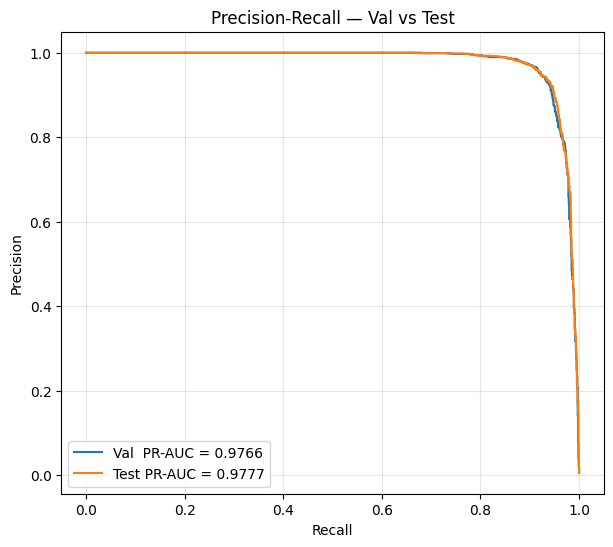

In [17]:
y_val_pred  = model.predict(X_val,  num_iteration=model.best_iteration)
y_test_pred = model.predict(X_test, num_iteration=model.best_iteration)

p_val,  r_val,  _ = precision_recall_curve(y_val,  y_val_pred)
p_test, r_test, _ = precision_recall_curve(y_test, y_test_pred)

ap_val  = average_precision_score(y_val,  y_val_pred)
ap_test = average_precision_score(y_test, y_test_pred)

plt.figure(figsize=(7, 6))
plt.plot(r_val,  p_val,  label=f"Val  PR-AUC = {ap_val:.4f}")
plt.plot(r_test, p_test, label=f"Test PR-AUC = {ap_test:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Val vs Test")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Calibration**

* The high PR-AUC, 0.977 on the validation set and 0.978 on the test set confirm that the model ranks fraudulent transactions above legitimate ones, but ranking quality alone does not guarantee that predicted scores correspond to true fraud probabilities

* We will assess calibration on the validation and test sets using reliability diagrams, comparing predicted score bins against observed fraud frequencies. If the curves deviate materially from the diagonal, the scores are miscalibrated and must be calibrated before use in production.

* If scores are not calibrated, we will fit an Isotonic Regression on the validation set and apply it to the test set and production data.

In [18]:
def plot_calibration_curve(y_val, val_pred, y_test, test_pred, calibration = 'Uncalibrated', n_bins=5):
    frac_pos_val,  mean_pred_val  = calibration_curve(y_val,  val_pred,  n_bins=n_bins, strategy="uniform")
    frac_pos_test, mean_pred_test = calibration_curve(y_test, test_pred, n_bins=n_bins, strategy="uniform")

    brier_val  = brier_score_loss(y_val,  val_pred)
    brier_test = brier_score_loss(y_test, test_pred)

    plt.rcParams.update({
        "figure.dpi": 120,
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
    })

    fig, (ax_cal, ax_hist) = plt.subplots(
        2, 1, figsize=(7.5, 8),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
        sharex=True,
    )

    ax_cal.plot([0, 1], [0, 1], color="#888", linestyle=":", linewidth=1.2,
                label="Perfect calibration")
    ax_cal.plot(mean_pred_val,  frac_pos_val,
                marker="o", markersize=6, linewidth=1.8, color="#1f77b4",
                label=f"Val   (Brier = {brier_val:.4f})")
    ax_cal.plot(mean_pred_test, frac_pos_test,
                marker="s", markersize=6, linewidth=1.8, color="#d62728",
                label=f"Test  (Brier = {brier_test:.4f})")

    ax_cal.set_ylabel("Fraction of positives")
    ax_cal.set_title(f"{calibration} — Val vs Test")
    ax_cal.set_xlim(-0.02, 1.02)
    ax_cal.set_ylim(-0.02, 1.02)
    ax_cal.legend(loc="upper left", frameon=False)

    bins = np.linspace(0, 1, 41)
    ax_hist.hist(val_pred,  bins=bins, histtype="step", linewidth=1.6, color="#1f77b4", label="Val")
    ax_hist.hist(test_pred, bins=bins, histtype="step", linewidth=1.6, color="#d62728", label="Test")
    ax_hist.set_yscale("log")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count (log)")
    ax_hist.legend(loc="upper right", frameon=False)

    plt.show()

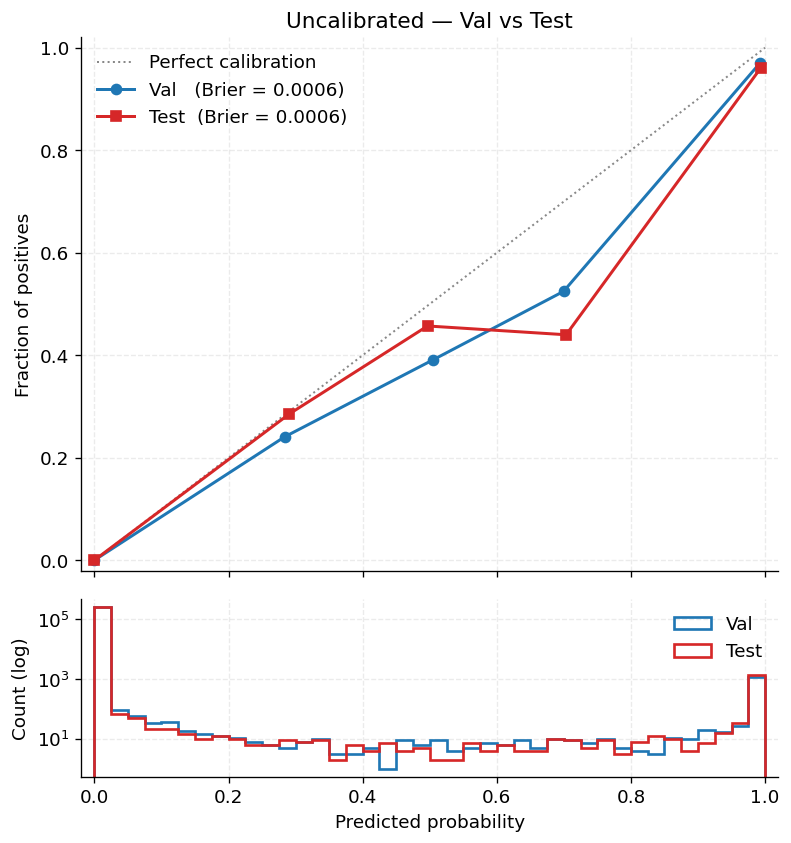

In [19]:
plot_calibration_curve(y_val, y_val_pred, y_test, y_test_pred, n_bins=5)

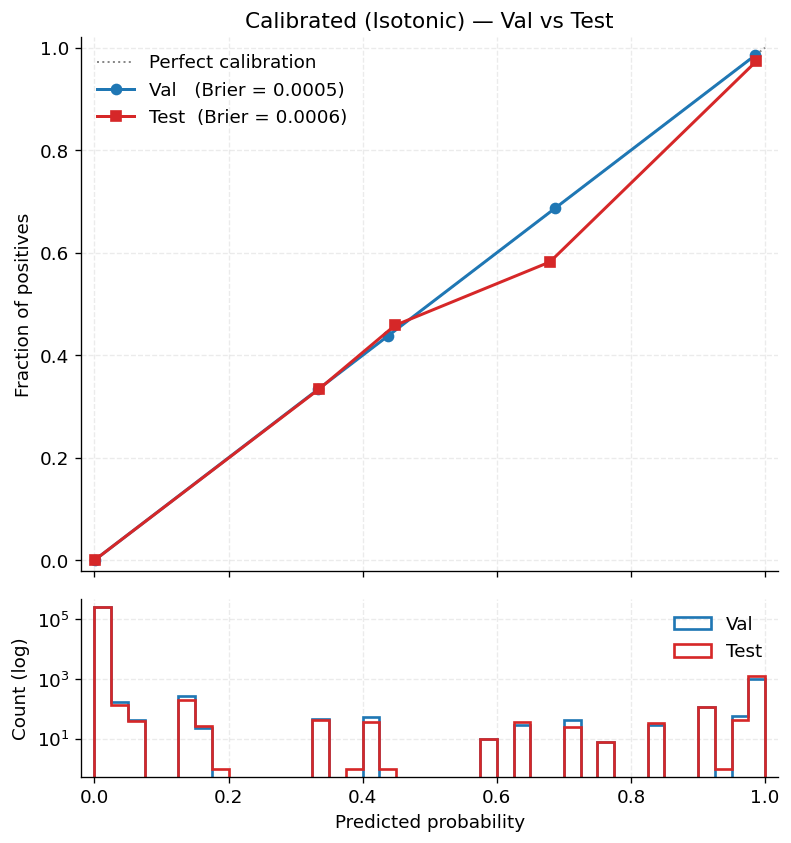

In [20]:
# Fit isotonic regression
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(y_val_pred, y_val)
y_test_iso = iso.transform(y_test_pred)
y_val_iso  = iso.transform(y_val_pred)

plot_calibration_curve(y_val, y_val_iso, y_test, y_test_iso, 'Calibrated (Isotonic)', n_bins=5)

# **Feature Importance**

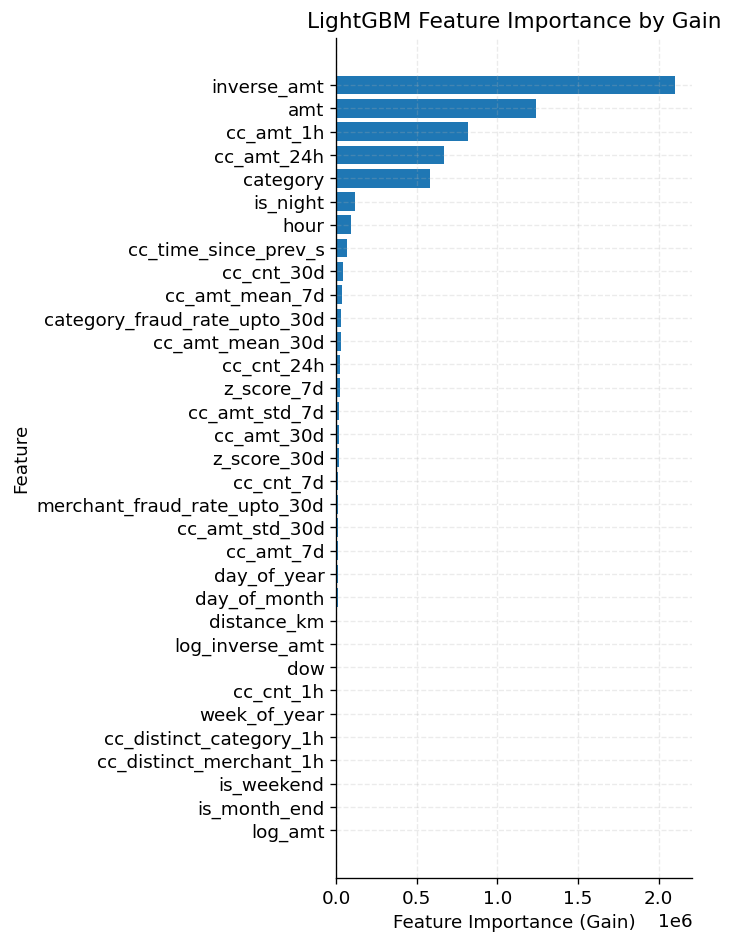

In [21]:
importance = model.feature_importance(importance_type='gain')
feature_names = model.feature_name()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importance})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(6, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.title('LightGBM Feature Importance by Gain')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Feature importance.**

**Top tier — transaction amount, short-window velocity and category.**

Inverse amount `inverse_amt` and amount `amt` are the strongest predictors of fraud. Amount in the last 1 hour `cc_amt_1h` and in the last 24 hours `cc_amt_24h` follow, confirming that short-horizon spend velocity, computed in real time and hourly respectively, is the next most informative signal. `category` is another top tier feature, indicating the concentration of fraud on specific categories.

**Mid tier — temporal and long-horizon baselines.**

Temporal features `is_night`, `hour`, and time since last transaction `cc_time_since_prev_s` are top mid-tier fraud signals. Nightly long-horizon baseline features, transaction count in the last 30 days `cc_cnt_30d`, amount mean in the last 7 days  `cc_amt_mean_7d`, in the last 30 days `cc_amt_mean_30d`, and the derived z-score values, `z_score_7d` and `z_score_30d`, contribute meaningfully. Categoy and merchant fraud priors `category_fraud_rate_upto_30d` and `merchant_fraud_rate_upto_30d` respectvely also carry fraud signals, validating the entity-level fraud priors as useful.

**Lower tier — geographic, calendar, and distinct-count features.**


Distance in km `distance_km`, calendar features (`day_of_year`, `day_of_month`, `dow`), and the 1-hour distinct-count features (`cc_distinct_category_1h`, `cc_distinct_merchant_1h`) contribute marginal signal. Transaction count in the last 1 hour `cc_cnt_1h` is surprisingly weak on its own, suggesting the amount-based 1-hour velocity `cc_amt_1h` carries much of the short-window velocity information.

# **Monitoring**

**PSI and CSI Helper Functions**

In [22]:
eps = 1e-6

# get quantile bin edges
def bin_edges(reference: np.ndarray, n_bins: int = 10) -> np.ndarray:
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(reference, qs))
    edges[0], edges[-1] = -np.inf, np.inf
    return edges

def distribution(x: np.ndarray, edges: np.ndarray) -> np.ndarray:
    counts = np.histogram(x, bins=edges)[0].astype(float)
    return (counts + eps) / (counts.sum() + eps * len(counts))


def psi(reference: np.ndarray, actual: np.ndarray, edges: np.ndarray) -> float:
    r, a = distribution(reference, edges), distribution(actual, edges)
    return float(np.sum((a - r) * np.log(a / r)))


# rule of thumb bands
def band(value: float) -> str:
    if value < 0.10:
        return "stable"
    if value < 0.25:
        return "moderate"
    return "material"


def csi_by_feature(ref: pd.DataFrame, act: pd.DataFrame, features: list[str]) -> dict[str, float]:
    out = {}
    for f in features:
        edges = bin_edges(ref[f].to_numpy())
        out[f] = psi(ref[f].to_numpy(), act[f].to_numpy(), edges)
    return out


In [23]:
val['fraud_score'] = y_val_iso
test['fraud_score'] = y_test_iso

In [24]:
val['dob'] = pd.to_datetime(val["dob"])
test['dob'] = pd.to_datetime(test["dob"])

val["age"] = ((val.trans_date_trans_time - val["dob"]).dt.days / 365.25).astype(np.float32)
test["age"] = ((test.trans_date_trans_time - test["dob"]).dt.days / 365.25).astype(np.float32)

val["age_bucket"] = pd.cut(val["age"], bins=[-np.inf, 25, 35, 50, 65, np.inf], labels=["<25", "25-35", "35-50", "50-65", "65+"],).astype(str)
test["age_bucket"] = pd.cut(test["age"], bins=[-np.inf, 25, 35, 50, 65, np.inf], labels=["<25", "25-35", "35-50", "50-65", "65+"],).astype(str)

In [25]:
def run_segement(reference: pd.DataFrame,
                 monitoring: pd.DataFrame,
                 dim: str,
                 cadence: str,
                 ts: str) -> dict:
    period = monitoring[ts].dt.to_period(cadence).astype(str)
    report = {}
    for seg in reference[dim].unique():
        seg_ref = reference[reference[dim] == seg]["fraud_score"].to_numpy()
        edges = bin_edges(seg_ref)
        seg_mon = monitoring[monitoring[dim] == seg]
        by_period = {'reference_segment_len': len(seg_ref),
                     'monitoring_segment_len': len(seg_mon)}

        for p, chunk in seg_mon.groupby(period):
            score_psi = psi(seg_ref, chunk["fraud_score"].to_numpy(), edges)
            entry = {"psi": score_psi, "band": band(score_psi)}

            # Drill into inputs when the score distribution materially moved.
            if band(score_psi) == "material":
                ref_feats = reference[reference[dim] == seg]
                entry["csi"] = csi_by_feature(ref_feats, chunk, NUMERIC_FEATURES)
            by_period[p] = entry
        report[seg] = by_period
    return report

In [26]:
def run_by_period(reference: pd.DataFrame,
                 monitoring: pd.DataFrame,
                 cadence: str,
                 ts: str) -> dict:
    edges = bin_edges(reference["fraud_score"].to_numpy())
    period = monitoring[ts].dt.to_period(cadence).astype(str)
    report = {}
    for p, chunk in monitoring.groupby(period):
        score_psi = psi(reference["fraud_score"].to_numpy(), chunk["fraud_score"].to_numpy(), edges)
        entry = {"psi": score_psi, "band": band(score_psi)}
        if band(score_psi) == "material":
            entry["csi"] = csi_by_feature(reference, chunk, NUMERIC_FEATURES)
        report[p] = entry
    return report

In [27]:
# JSON loader helper
def convert_numpy_types(obj):
    if isinstance(obj, dict):
        # Convert keys and values in a dictionary
        return {convert_numpy_types(k): convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        # Convert elements in a list
        return [convert_numpy_types(elem) for elem in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.bool_):
        return bool(obj)
    return obj

# **PSI Drift Monitoring**

To detect drift between the validation and the test period, we will compute monthly PSI on the monitoring window (test set) against the reference distribution (validation set).

PSI is evaluated at the global population level and across five  dimensions:

- `category`
- `state`
- `gender`
- `is_night`
- `age_bucket`

Segment-month PSI values are bucketed into `stable` (< 0.10), `moderate` (0.10 – 0.25), and `major` (≥ 0.25).

In [28]:
dimensions = ['category', 'state', 'gender', 'is_night', 'age_bucket']

report = {}
for dim in dimensions:
    report[dim] = run_segement(val, test, dim, 'M', 'trans_date_trans_time')
report['all_segments'] = run_by_period(val, test, 'M', 'trans_date_trans_time')

json_report = convert_numpy_types(report)
print(json.dumps(json_report, indent=4))

{
    "category": {
        "personal_care": {
            "reference_segment_len": 18106,
            "monitoring_segment_len": 18006,
            "2020-03": {
                "psi": 0.045619829353254995,
                "band": "stable"
            },
            "2020-04": {
                "psi": 0.07591421825937605,
                "band": "stable"
            },
            "2020-05": {
                "psi": 0.06145372735397173,
                "band": "stable"
            },
            "2020-06": {
                "psi": 0.07557913471780661,
                "band": "stable"
            }
        },
        "shopping_pos": {
            "reference_segment_len": 23401,
            "monitoring_segment_len": 23342,
            "2020-03": {
                "psi": 0.0007004356998639498,
                "band": "stable"
            },
            "2020-04": {
                "psi": 0.007220150437779064,
                "band": "stable"
            },
            "2020-05": {
        



**Global drift:**

The overall population is stable across the entire window: PSI = 0.0059 (Mar), 0.0110 (Apr), 0.0087 (May), 0.0171 (Jun). A mild upward trend is visible into June but remains an order of magnitude below the moderate threshold.

**Segment-level findings:**

Of the 292 segment-month evaluations, **290 are stable and 2 are moderate**. No segment reaches the major-drift band.

| Band | Count | Share |
|---|---|---|
| stable | 290 | 99.3% |
| moderate | 2 | 0.7% |
| major | 0 | 0.0% |

**Moderate-drift segments.**

| Dimension | Segment | Month | PSI | Band |
|---|---|---|---|---|
| state | VT | 2020-06 | 0.1055 | moderate |
| state | RI | 2020-05 | 0.1029 | moderate |

Both PSI values only marginally above the 0.10 threshold and neither exhibits sustained multi-month drift.


# **PR AUC Control Chart**

**Weekly PR-AUC control chart:**

We will track model performance on a weekly cadence using a PR-AUC control chart against the validation reference set.

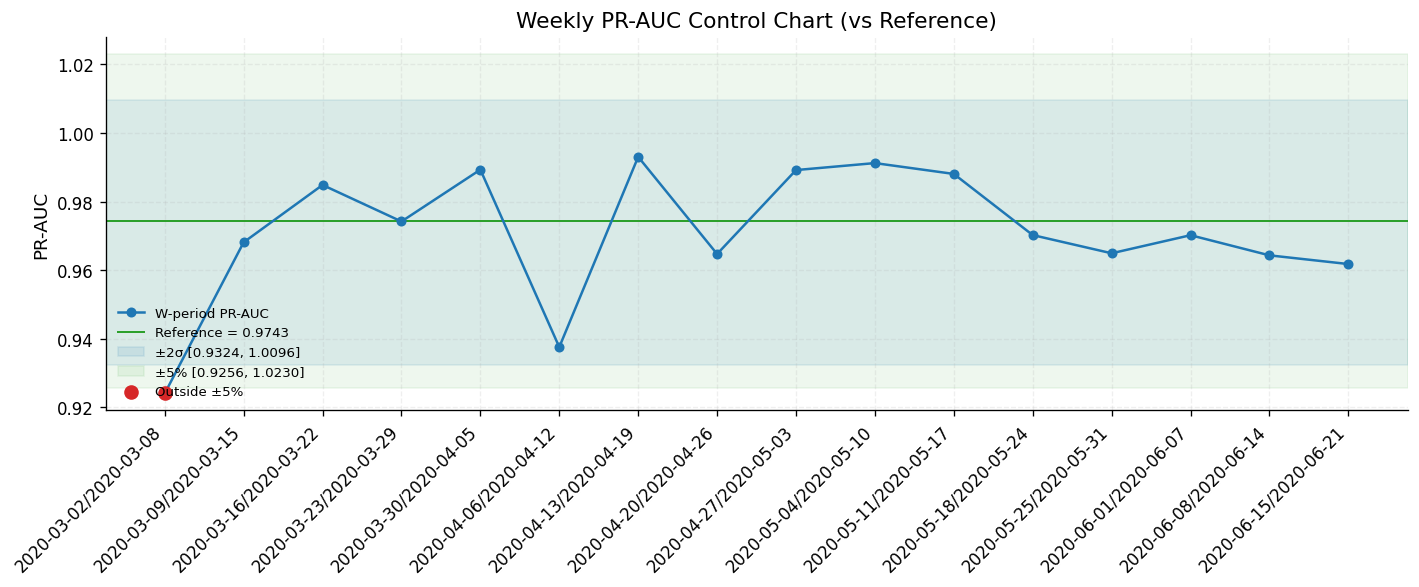

In [29]:
def stability_performance_control_chart(reference: pd.DataFrame,
                          scored_labeled: pd.DataFrame,
                          cadence: str = "W",
                          ts: str = "trans_date_trans_time",
                          score_col: str = "fraud_score",
                          label_col: str = "is_fraud",
                          min_rows: int = 100,
                          min_fraud: int = 3,
                          plot: bool = True):

    ref_pr = average_precision_score(reference[label_col],
                                     reference[score_col])

    period = scored_labeled[ts].dt.to_period(cadence).astype(str)
    rows = []

    for p, chunk in scored_labeled.groupby(period, sort=True):
        y_w = chunk[label_col].values
        s_w = chunk[score_col].values

        if len(s_w) < min_rows or y_w.sum() < min_fraud:
            continue

        pr = average_precision_score(y_w, s_w)
        pct_change = (pr - ref_pr) / ref_pr * 100


        rows.append({"period": p, "n": len(s_w), "n_fraud": int(y_w.sum()),
                     "PR-AUC": pr, "%Δ": pct_change})


    results = pd.DataFrame(rows)

    # bands
    pr_mean = results["PR-AUC"].mean()
    pr_std = results["PR-AUC"].std()
    upper_2s = pr_mean + 2 * pr_std
    lower_2s = pr_mean - 2 * pr_std
    upper_5 = ref_pr * 1.05
    lower_5 = ref_pr * 0.95

    results["in_5pct"] = results["PR-AUC"].between(lower_5, upper_5)
    n_in = int(results["in_5pct"].sum())
    n_total = len(results)

    if plot:
        plt.rcParams.update({
            "figure.dpi": 120,
            "font.size": 10,
            "axes.spines.top": False,
            "axes.spines.right": False,
        })

        fig, ax = plt.subplots(figsize=(12, 5))

        x = range(len(results))

        ax.plot(x, results["PR-AUC"], marker="o", markersize=5, linewidth=1.5,
                 color="#1f77b4", label=f"{cadence}-period PR-AUC", zorder=3)
        ax.axhline(ref_pr, color="#2ca02c", linestyle="-", linewidth=1.2,
                    label=f"Reference = {ref_pr:.4f}")
        ax.axhspan(lower_2s, upper_2s, alpha=0.10, color="#1f77b4",
                    label=f"±2σ [{lower_2s:.4f}, {upper_2s:.4f}]")
        ax.axhspan(lower_5, upper_5, alpha=0.08, color="#2ca02c",
                    label=f"±5% [{lower_5:.4f}, {upper_5:.4f}]")

        outside = ~results["in_5pct"].values
        if outside.any():
            ax.scatter(np.where(outside)[0], results.loc[outside, "PR-AUC"],
                        color="#d62728", s=60, zorder=4, label="Outside ±5%")

        ax.set_xticks(list(x))
        ax.set_xticklabels(results["period"].values, rotation=45, ha="right")
        ax.set_ylabel("PR-AUC")
        ax.set_title(f"Weekly PR-AUC Control Chart (vs Reference)")
        ax.legend(loc="lower left", fontsize=8, frameon=False)
        ax.grid(alpha=0.2)

        plt.tight_layout()
        plt.show()
stability_performance_control_chart(val, test)

* Across the 17-week monitoring window (2020-03-02 through 2020-06-21), all weekly, except the first two, PR-AUC values sit within the ±5% tolerance and ±2 σ band. The first two weeks sit at the edge of the ±2 σ band and well inside a ±10% tolerance band.

* Model ranking performance is stable against the validation period, consistent with the PSI monitoring result showing no material drift.